In [2]:
import os

print(os.getcwd())

d:\New_26\AI_Assistant_Car_Pricing\ml_notebooks


In [3]:
print(os.listdir())

['Feature_engineering.ipynb', 'rand_forest.ipynb', 'xgboost_target.ipynb']


In [4]:
import pandas as pd

df = pd.read_csv("../data/cars_ml_onehot.csv")

In [ ]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 243769 entries, 0 to 243768
Data columns (total 78 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   price_in_euro                     243769 non-null  int64  
 1   power_kw                          243769 non-null  float64
 2   fuel_consumption_l_100km          243769 non-null  float64
 3   co2_emissions_g_km                243769 non-null  float64
 4   mileage_in_km                     243769 non-null  float64
 5   price_log                         243769 non-null  float64
 6   car_age                           243769 non-null  int64  
 7   has_fuel_consumption              243769 non-null  int64  
 8   has_co2                           243769 non-null  int64  
 9   is_electric                       243769 non-null  int64  
 10  model_frequency                   243769 non-null  int64  
 11  brand_aston-martin                243769 non-null  int64  
 12 

,price_in_euro,power_kw,fuel_consumption_l_100km,co2_emissions_g_km,mileage_in_km,price_log,car_age,has_fuel_consumption,has_co2,is_electric,...,color_grey,color_orange,color_red,color_silver,color_violet,color_white,color_yellow,transmission_type_Manual,transmission_type_Semi-automatic,transmission_type_Unknown
0,1300,148.0,10.0,260.0,160500.0,7.170888,31,1,1,0,...,0,0,1,0,0,0,0,1,0,0
1,24900,191.0,6.0,320.0,190000.0,10.122663,31,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,5900,110.0,6.0,220.0,129000.0,8.682877,31,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4900,110.0,9.0,225.0,189500.0,8.497195,31,1,1,0,...,0,0,0,0,0,0,0,1,0,0
4,17950,132.0,7.0,320.0,96127.0,9.795401,30,1,0,0,...,0,0,1,0,0,0,0,1,0,0


In [3]:
X = df.drop(columns=['price_in_euro', 'price_log'])
y = df['price_log']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [6]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [7]:
pred_log = rf.predict(X_test)

In [8]:
import numpy as np

pred_price = np.exp(pred_log)
true_price = np.exp(y_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))
r2 = r2_score(true_price, pred_price)

print(f"MAE : {mae:.2f} €")
print(f"RMSE: {rmse:.2f} €")
print(f"R²  : {r2:.4f}")

MAE : 3335.45 €
RMSE: 11014.49 €
R²  : 0.8907


In [10]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(20))

                     Feature  Importance
4                    car_age    0.513051
0                   power_kw    0.335501
3              mileage_in_km    0.060512
2         co2_emissions_g_km    0.022296
8            model_frequency    0.018907
58          fuel_type_Petrol    0.004756
73  transmission_type_Manual    0.004439
1   fuel_consumption_l_100km    0.004003
53          brand_volkswagen    0.003728
37       brand_mercedes-benz    0.003437
43             brand_porsche    0.003304
41                brand_opel    0.002694
23                brand_ford    0.002329
10                brand_audi    0.002003
60               color_black    0.001476
69              color_silver    0.001230
12                 brand_bmw    0.001184
34          brand_land-rover    0.001174
61                color_blue    0.001114
6                    has_co2    0.001104


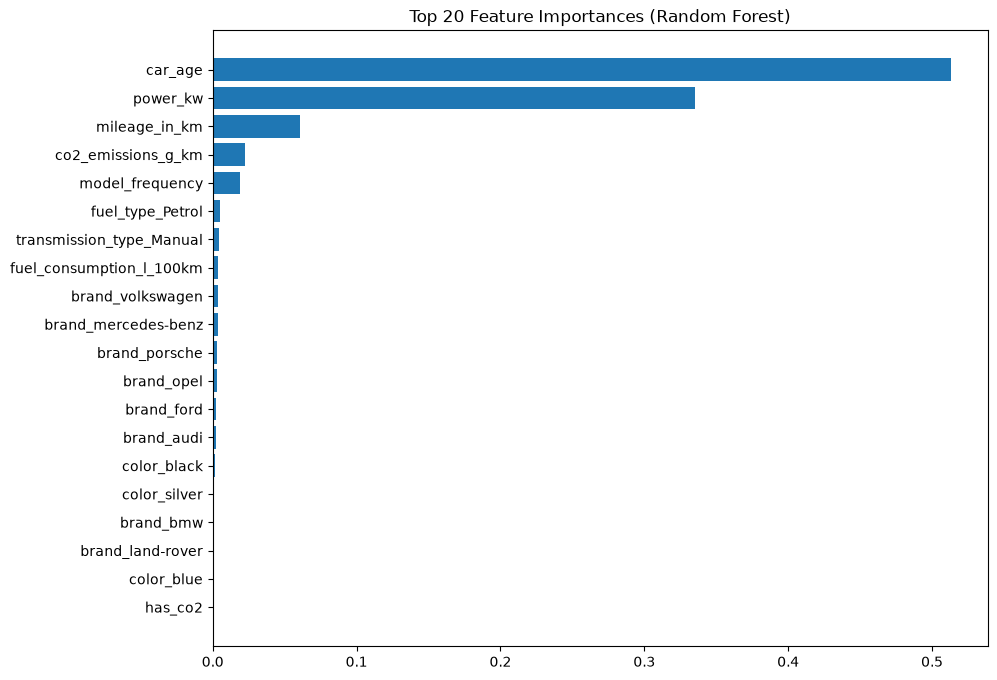

In [11]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20['Feature'], top20['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()

In [1]:
import joblib

model = joblib.load(
    "../models/price_model.pkl"
)

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
